In [12]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# Load fMRI data (4D: X, Y, Z, T)
fmri_file = "/home/aghaffari/adni/preprocessed/002_0413/func/fmri_MNI_preprocessed.nii.gz"
fmri = nib.load(fmri_file).get_fdata()

# reshape: (voxels, time)
n_voxels = np.prod(fmri.shape[:3])
n_time = fmri.shape[3]

data = fmri.reshape(n_voxels, n_time)

# optional: remove constant/low-variance voxels
std = np.std(data, axis=1)
data = data[std > 1e-6]

# normalize each voxel (important!)
data = (data - data.mean(axis=1, keepdims=True)) / data.std(axis=1, keepdims=True)

raw_add = "/home/aghaffari/adni/preprocessed/002_0413/func/fmri_input_MNI.nii.gz"
raw = nib.load(raw_add).get_fdata()

# reshape: (voxels, time)
n_voxels = np.prod(raw.shape[:3])
n_time = raw.shape[3]

raw = raw.reshape(n_voxels, n_time)

# optional: remove constant/low-variance voxels
std = np.std(raw, axis=1)
raw = raw[std > 1e-6]

# normalize each voxel (important!)
raw = (raw - raw.mean(axis=1, keepdims=True)) / raw.std(axis=1, keepdims=True)

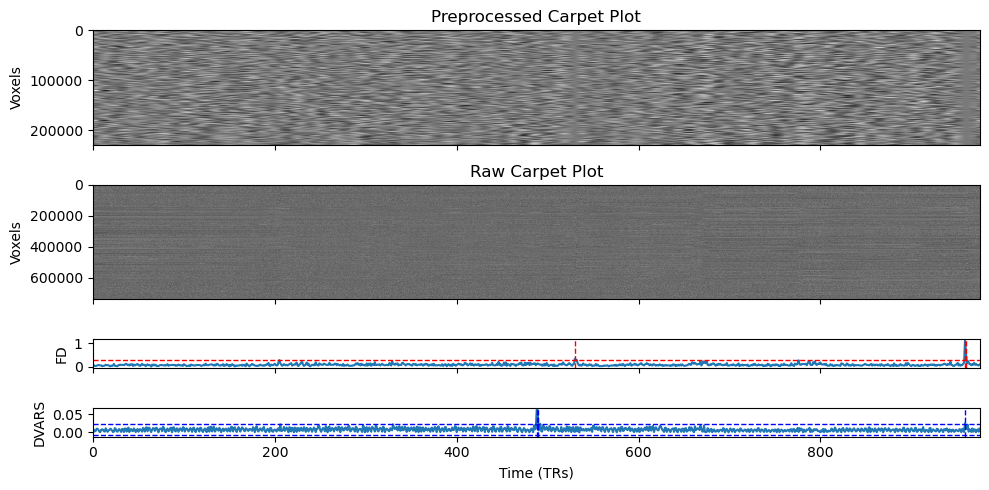

In [16]:
import matplotlib.pyplot as plt
import numpy as np

motion_file = "/home/aghaffari/adni/preprocessed/002_0413/func/confounds/framewise.txt"
dvars_file = "/home/aghaffari/adni/preprocessed/002_0413/func/confounds/dvars_values.txt"

z = np.loadtxt(motion_file)
dvars = np.loadtxt(dvars_file)

fig, axes = plt.subplots(
    4, 1,
    figsize=(10, 5),
    sharex=True,
    gridspec_kw={'height_ratios': [4,4, 1, 1]}
)

# --- carpet ---
axes[0].imshow(
    data,
    aspect='auto',
    cmap='gray',
    interpolation='nearest'
)
axes[0].set_ylabel("Voxels")
axes[0].set_title("Preprocessed Carpet Plot")

axes[1].imshow(
    raw,
    aspect='auto',
    cmap='gray',
    interpolation='nearest'
)
axes[1].set_ylabel("Voxels")
axes[1].set_title("Raw Carpet Plot")

# --- FD ---
axes[2].plot(z)
axes[2].set_ylabel("FD")

# --- DVARS ---
axes[3].plot(dvars)
axes[3].set_ylabel("DVARS")
axes[3].set_xlabel("Time (TRs)")

# --- FD threshold ---
fd_threshold = 0.3
axes[2].axhline(fd_threshold, color='red', linestyle='--', linewidth=1)

fd_spikes = np.where(z > fd_threshold)[0]
for s in fd_spikes:
    axes[2].axvline(s, color='red', linestyle='--', linewidth=1)

# --- DVARS threshold (3 std) ---
dvars_mean = np.mean(dvars)
dvars_std = np.std(dvars)

if dvars_std != 0:
    dvars_z = (dvars - dvars_mean) / dvars_std
    dvars_spikes = np.where(np.abs(dvars_z) > 3)[0]

    # optional: horizontal line (threshold in original units)
    upper_thr = dvars_mean + 3 * dvars_std
    lower_thr = dvars_mean - 3 * dvars_std
    axes[3].axhline(upper_thr, color='blue', linestyle='--', linewidth=1)
    axes[3].axhline(lower_thr, color='blue', linestyle='--', linewidth=1)

    for s in dvars_spikes:
        axes[3].axvline(s, color='blue', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

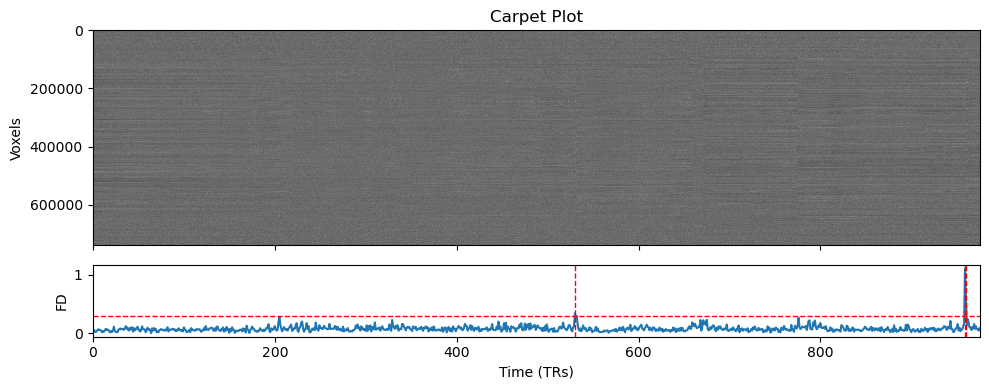

In [4]:
import matplotlib.pyplot as plt
import numpy as np
motion_file = "/home/aghaffari/adni/preprocessed/002_0413/func/confounds/framewise.txt"
z = np.loadtxt(motion_file)

T = data.shape[1]
z = z[:T]  # align length

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 4),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# --- carpet ---
axes[0].imshow(
    data,
    aspect='auto',
    cmap='gray',
    interpolation='nearest'
)
axes[0].set_ylabel("Voxels")
axes[0].set_title("Carpet Plot")

# --- motion ---
axes[1].plot(z)
axes[1].set_ylabel("FD")
axes[1].set_xlabel("Time (TRs)")

# --- threshold ---
threshold = 0.3

# horizontal threshold line
axes[1].axhline(threshold, color='red', linestyle='--', linewidth=1)

# vertical spike lines
spikes = np.where(z > threshold)[0]
for s in spikes:
    
    axes[1].axvline(s, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()